<a href="https://colab.research.google.com/github/NamSee04/CS114.P11/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [96]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [97]:
import numpy as np

In [98]:
# Define the path to the .npz file
npz_path = '/content/drive/MyDrive/features_and_paths.npz'

# Load the .npz file
data = np.load(npz_path)

In [99]:
features = data['features']
paths = data['paths']

In [100]:
!pip install faiss-cpu

In [101]:
class DSU:
    def __init__(self, n):
        self.e = [-1] * n

    def find(self, val):
        if self.e[val] < 0:
            return val
        self.e[val] = self.find(self.e[val])
        return self.e[val]

    def size(self, val):
        return -self.e[self.find(val)]

    def same(self, a, b):
        return self.find(a) == self.find(b)

    def unite(self, a, b):
        a = self.find(a)
        b = self.find(b)
        if a == b:
            return False
        if self.e[a] > self.e[b]:
            a, b = b, a
        self.e[a] += self.e[b]
        self.e[b] = a
        return True


In [102]:
import faiss

index = faiss.IndexFlatL2(features.shape[1])
index.add(features)
threshold = 30
distances, indices = index.search(features, 50)

dsu = DSU(len(features))

for i in range(len(distances)):
    # Lọc các lân cận nằm trong ngưỡng khoảng cách
    valid_neighbors = [idx for dist, idx in zip(distances[i], indices[i]) if dist <= threshold]
    for val in valid_neighbors:
        dsu.unite(i, val)

In [103]:
from collections import defaultdict

# Assuming 'cluster' is already populated
cluster = defaultdict(set)

# Populate the cluster dictionary (example)
for i in range(len(features)):
    cluster[dsu.find(i)].add(i)

sorted_cluster = sorted(cluster.items(), key=lambda item: len(item[1]), reverse=True)


Cluster Key: 29549 

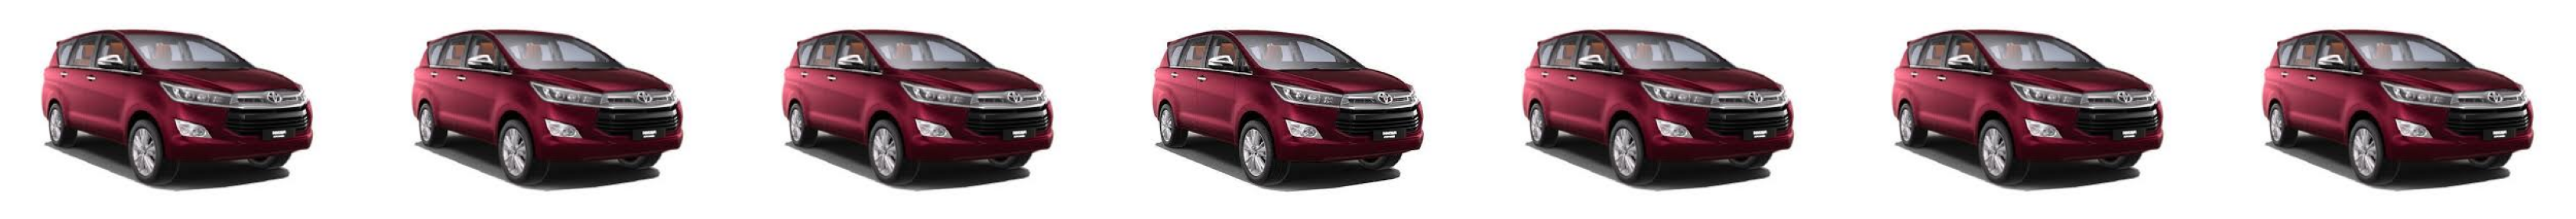

Cluster Key: 29550 

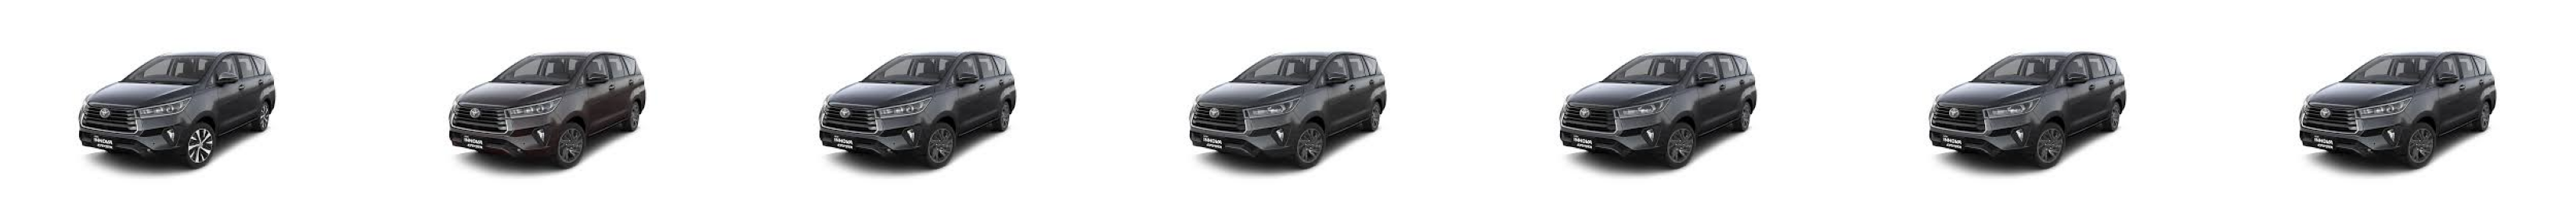

Cluster Key: 29562 

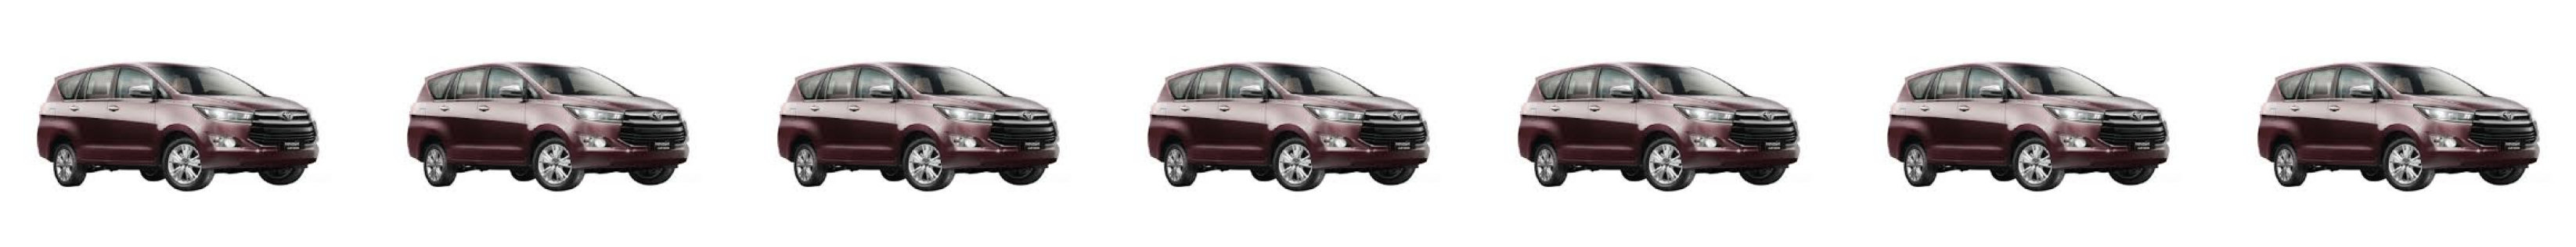

Cluster Key: 29582 

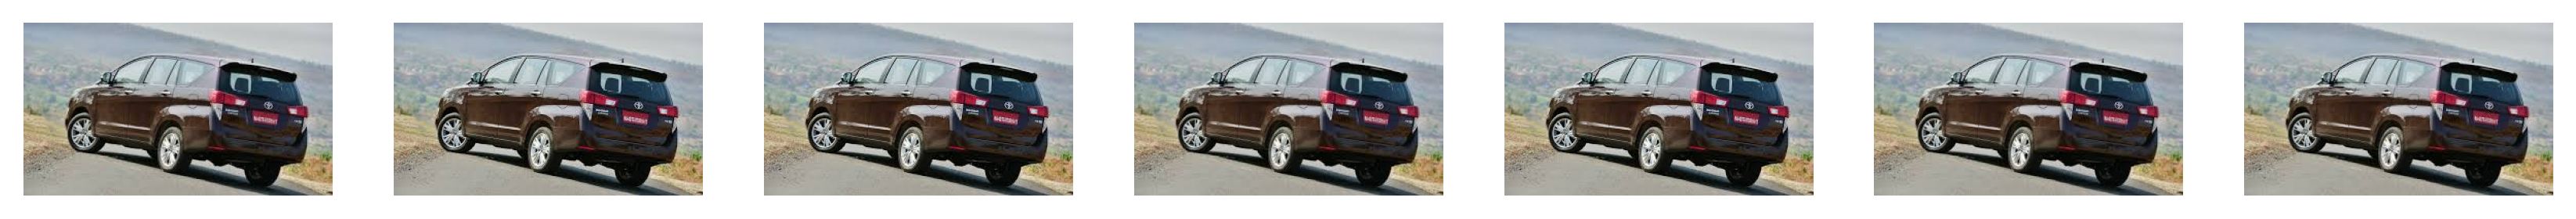

Cluster Key: 29673 

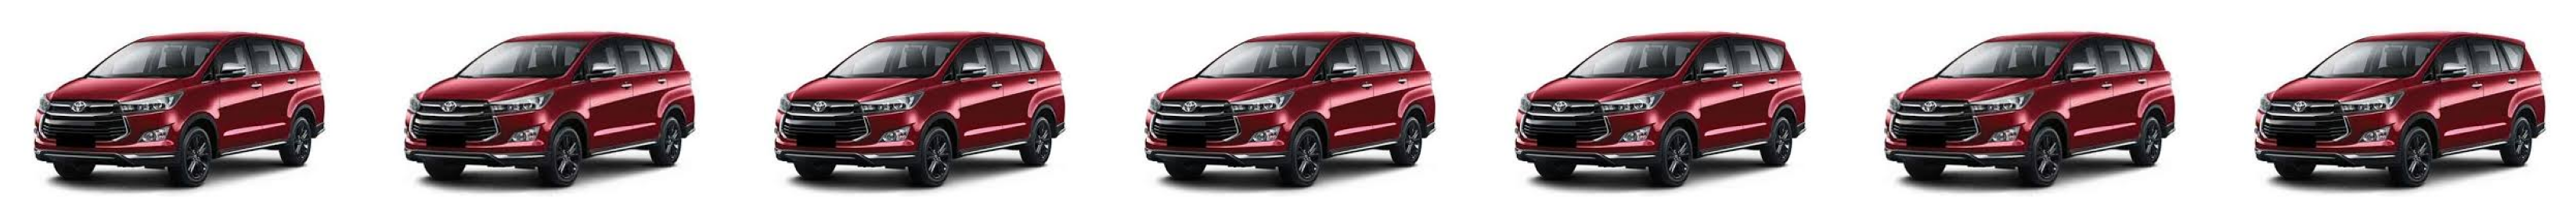

In [104]:

for key, value in sorted_cluster[0:5]:
    print(f"Cluster Key: {key}", end=" ") # Print cluster key in the same row
    count = 0
    plt.figure(figsize=(20, 5), dpi = 300) # Adjust figure size as needed
    for idx in value:
      if count < 10:
        try:
          img = Image.open(paths[idx])
          plt.subplot(1, 10, count + 1) # Adjust subplot grid if necessary
          plt.imshow(img)
          plt.axis('off')
          count += 1
        except Exception as e:
          print(f"Error loading image {paths[idx]}: {e}")
    plt.show()

In [113]:
print("Số ảnh trùng: ", len(features) - len(sorted_cluster))

Số ảnh trùng:  2223
